# Isolation Forest — Anomaly Detection
## Module 3: Anomaly Detection
Using the Iris dataset with injected anomalies to demonstrate Isolation Forest.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix
import joblib
import os

np.random.seed(42)
print('Libraries loaded successfully!')

Libraries loaded successfully!


## 1. Load Iris & Inject Anomalies

In [2]:
iris = load_iris()
X_normal = iris.data
y_species = iris.target
feature_names = iris.feature_names

# Inject 20 synthetic anomalies — random values well outside normal range
n_anomalies = 20
X_anomalies = np.random.uniform(low=-2, high=10, size=(n_anomalies, X_normal.shape[1]))

X = np.vstack([X_normal, X_anomalies])
y_true = np.array([1]*len(X_normal) + [-1]*n_anomalies)  # 1=normal, -1=anomaly

df = pd.DataFrame(X, columns=feature_names)
df['label'] = ['normal' if l == 1 else 'anomaly' for l in y_true]

os.makedirs('../data', exist_ok=True)
df.to_csv('../data/iris_with_anomalies.csv', index=False)

print(f'Total samples : {len(X)}')
print(f'Normal samples: {len(X_normal)}')
print(f'Anomalies     : {n_anomalies}')
df.head()

Total samples : 170
Normal samples: 150
Anomalies     : 20


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),label
0,5.1,3.5,1.4,0.2,normal
1,4.9,3.0,1.4,0.2,normal
2,4.7,3.2,1.3,0.2,normal
3,4.6,3.1,1.5,0.2,normal
4,5.0,3.6,1.4,0.2,normal


## 2. Exploratory Data Analysis

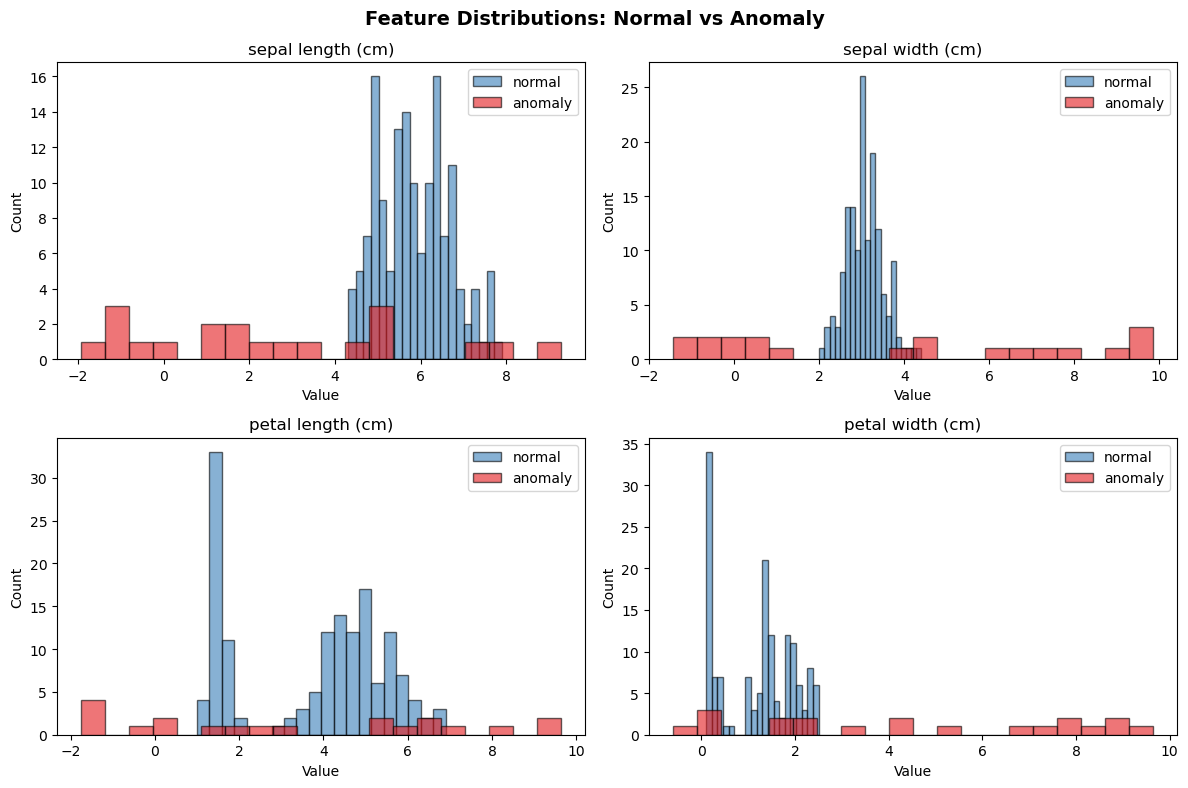

Plot saved.


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feat in enumerate(feature_names):
    for label, color in [('normal', '#377eb8'), ('anomaly', '#e41a1c')]:
        subset = df[df['label'] == label][feat]
        axes[i].hist(subset, bins=20, alpha=0.6, color=color, label=label, edgecolor='black')
    axes[i].set_title(feat)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
    axes[i].legend()

plt.suptitle('Feature Distributions: Normal vs Anomaly', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/feature_distributions.png', dpi=150)
plt.show()
print('Plot saved.')

## 3. Preprocessing — Standardization

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print('Scaling done. Shape:', X_scaled.shape)

Scaling done. Shape: (170, 4)


## 4. What is Isolation Forest?
Isolation Forest detects anomalies by **randomly isolating observations**:
- Build many random decision trees
- Anomalies are isolated closer to the root (fewer splits needed)
- An **anomaly score** is computed from average path length
- Key parameter: `contamination` — expected fraction of anomalies

## 5. Train Isolation Forest

In [5]:
contamination = n_anomalies / len(X)  # ~0.118
print(f'Contamination rate: {contamination:.3f}')

iso_forest = IsolationForest(
    n_estimators=100,
    contamination=contamination,
    random_state=42
)
iso_forest.fit(X_scaled)

y_pred = iso_forest.predict(X_scaled)          # 1=normal, -1=anomaly
scores  = iso_forest.decision_function(X_scaled)  # higher = more normal

df['predicted'] = ['anomaly' if p == -1 else 'normal' for p in y_pred]
df['anomaly_score'] = scores
df.to_csv('../data/iris_predictions.csv', index=False)

print('\nPrediction counts:')
print(df['predicted'].value_counts())

Contamination rate: 0.118

Prediction counts:
predicted
normal     150
anomaly     20
Name: count, dtype: int64


## 6. Evaluation

Classification Report:
              precision    recall  f1-score   support

Anomaly (-1)       1.00      1.00      1.00        20
  Normal (1)       1.00      1.00      1.00       150

    accuracy                           1.00       170
   macro avg       1.00      1.00      1.00       170
weighted avg       1.00      1.00      1.00       170



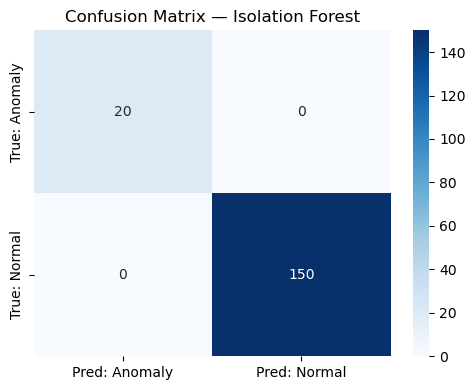

In [6]:
print('Classification Report:')
print(classification_report(y_true, y_pred, target_names=['Anomaly (-1)', 'Normal (1)']))

cm = confusion_matrix(y_true, y_pred, labels=[-1, 1])
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred: Anomaly', 'Pred: Normal'],
            yticklabels=['True: Anomaly', 'True: Normal'])
plt.title('Confusion Matrix — Isolation Forest')
plt.tight_layout()
plt.savefig('../data/confusion_matrix.png', dpi=150)
plt.show()

## 7. Anomaly Score Distribution

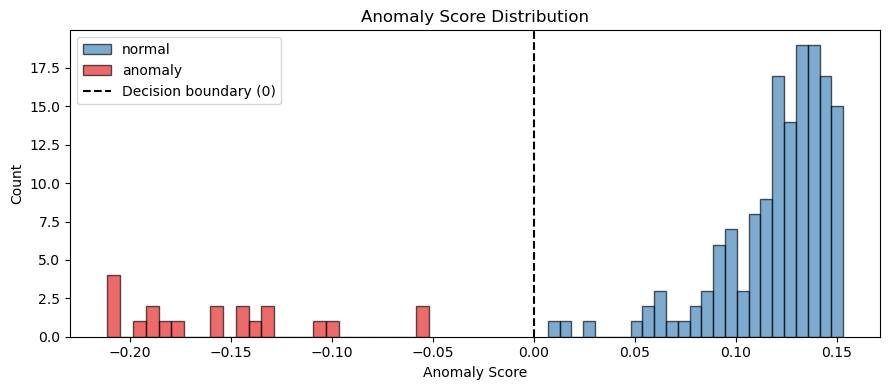

In [7]:
plt.figure(figsize=(9, 4))
for label, color in [('normal', '#377eb8'), ('anomaly', '#e41a1c')]:
    subset = df[df['label'] == label]['anomaly_score']
    plt.hist(subset, bins=25, alpha=0.65, color=color, label=label, edgecolor='black')

plt.axvline(0, linestyle='--', color='black', label='Decision boundary (0)')
plt.xlabel('Anomaly Score')
plt.ylabel('Count')
plt.title('Anomaly Score Distribution')
plt.legend()
plt.tight_layout()
plt.savefig('../data/anomaly_score_dist.png', dpi=150)
plt.show()

## 8. PCA Visualization of Detections

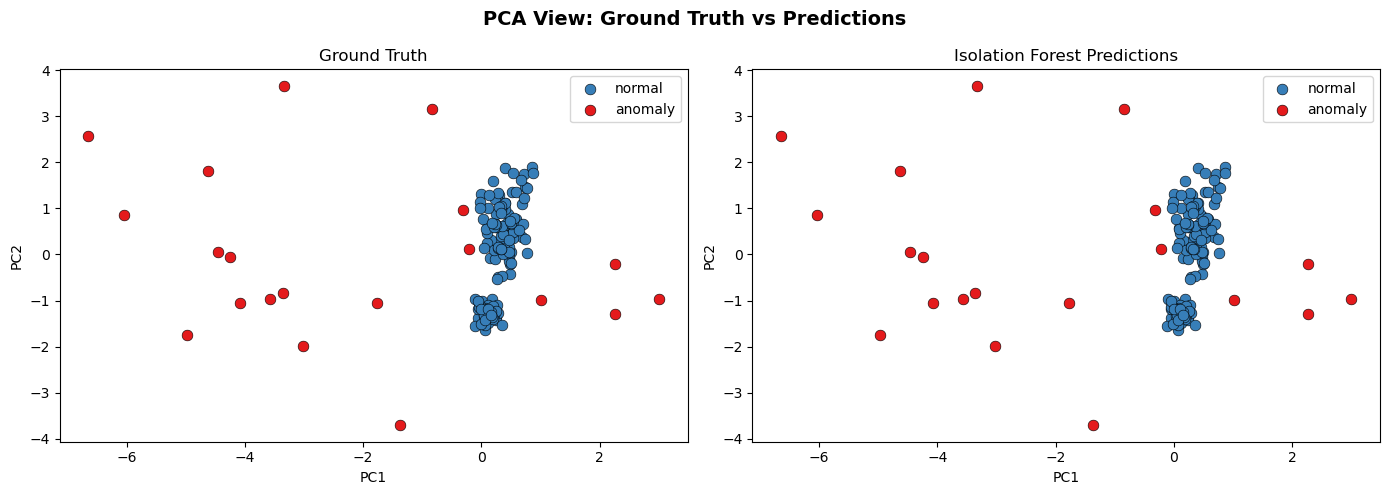

In [8]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Ground truth
for label, color in [('normal', '#377eb8'), ('anomaly', '#e41a1c')]:
    mask = df['label'] == label
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], c=color, label=label,
                    s=60, edgecolors='k', linewidths=0.4)
axes[0].set_title('Ground Truth')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].legend()

# Predictions
for label, color in [('normal', '#377eb8'), ('anomaly', '#e41a1c')]:
    mask = df['predicted'] == label
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1], c=color, label=label,
                    s=60, edgecolors='k', linewidths=0.4)
axes[1].set_title('Isolation Forest Predictions')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
axes[1].legend()

plt.suptitle('PCA View: Ground Truth vs Predictions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/pca_detections.png', dpi=150)
plt.show()

## 9. Effect of Contamination Parameter

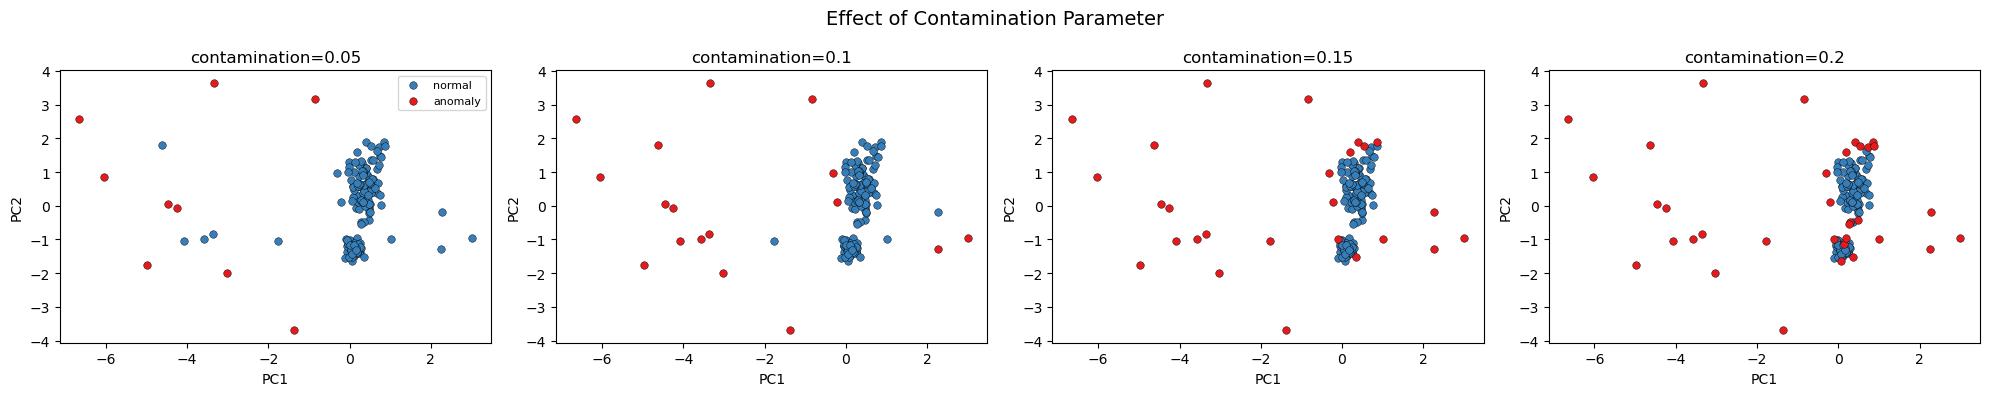

In [9]:
contamination_values = [0.05, 0.10, 0.15, 0.20]
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for ax, cont in zip(axes, contamination_values):
    model = IsolationForest(n_estimators=100, contamination=cont, random_state=42)
    preds = model.fit_predict(X_scaled)
    for val, color, label in [(1, '#377eb8', 'normal'), (-1, '#e41a1c', 'anomaly')]:
        mask = preds == val
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=color, label=label,
                   s=30, edgecolors='k', linewidths=0.3)
    ax.set_title(f'contamination={cont}')
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')

axes[0].legend(fontsize=8)
plt.suptitle('Effect of Contamination Parameter', fontsize=14)
plt.tight_layout()
plt.savefig('../data/contamination_effect.png', dpi=150)
plt.show()

## 10. Save Model

In [10]:
os.makedirs('../models', exist_ok=True)
joblib.dump(scaler,     '../models/scaler.pkl')
joblib.dump(iso_forest, '../models/isolation_forest.pkl')
print('Models saved to models/')

Models saved to models/


## Summary
| Metric | Value |
|---|---|
| Algorithm | Isolation Forest |
| Dataset | Iris + 20 injected anomalies |
| n_estimators | 100 |
| Contamination | ~0.118 |
| Key insight | Anomalies need fewer splits to isolate → shorter path length → lower score |

**Takeaway:** Isolation Forest is fast, scalable, and requires no labeled data — ideal for unsupervised anomaly detection.